# Experimento 5 — Bloque B: Valor Económico de la Predicción Probabilística

**Objetivo:** Cuantificar el valor económico real de usar predicciones cuantílicas (Exp 3)  
en lugar de predicciones puntuales (Exp 1). ¿Cuánto ahorra elegir el cuantil óptimo?  
¿Cuánto vale la calibración conformal (CQR)? ¿Qué brecha queda con el oracle?

**Planta:** TALASOL (única planta de Exp 3 — planta target de transferencia)  
**Marco regulatorio:** P.O. 14.4 — Liquidación de desvíos del sistema eléctrico peninsular.

**Dependencias previas:**
- `ex3_probabilistic/01_lstm_quantile.ipynb` → `results/ex3_probabilistic/lstm/predictions_TALASOL.csv`
- `ex3_probabilistic/02_tft_quantile.ipynb` → `results/ex3_probabilistic/tft/predictions_TALASOL.csv`
- `ex3_probabilistic/02_tft_quantile.ipynb` → `results/ex3_probabilistic/tft/predictions_TALASOL_CQR.csv`
- `ex1_compare/05_baseline_tft.ipynb` → `results/ex1_compare/metrics/tft_predictions.csv`

**Bloques:**
1. Carga de datos (precios ESIOS + predicciones cuantílicas)
2. Estrategias de oferta fija (usar cada cuantil directamente)
3. Estrategia dinámica Newsvendor (cuantil óptimo hora a hora)
4. EVPI — Expected Value of Perfect Information
5. Valor de la calibración CQR
6. Comparación global Exp 1 vs Exp 3
7. Análisis de riesgo — VaR y CVaR diario
8. Resumen y exportación

In [1]:
##########################################
# Añadir esto al principio de cada ipynb #
##########################################
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/')

# Verifica que existan las carpetas esperadas
!ls
# Debes ver 'src' y 'config'

Mounted at /content/drive
checkpoints  data  lightning_logs  README.md	     results
config	     doc   notebooks	   requirements.txt  src


In [2]:
# ---------------------------------------------------------------------------
# CELDA 1 — Setup Colab / Local
# ---------------------------------------------------------------------------
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO = '/content/drive/MyDrive/_UOC/tfm-solar-forecasting/'
    os.chdir(REPO)
    print(f'Working dir: {os.getcwd()}')

if 'src' not in sys.path[0]:
    sys.path.insert(0, os.path.abspath('.'))
    sys.path.insert(0, os.path.abspath('src'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

print('Setup completado.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/_UOC/tfm-solar-forecasting
Setup completado.


In [3]:
# ---------------------------------------------------------------------------
# CELDA 2 — Configuración global
# ---------------------------------------------------------------------------
ROOT     = Path('.')
ESIOS_DIR = ROOT / 'data' / 'esios'
EX1_DIR   = ROOT / 'results' / 'ex1_compare'
EX3_DIR   = ROOT / 'results' / 'ex3_probabilistic'
OUT_DIR   = ROOT / 'results' / 'ex4_valuation'
FIG_DIR   = ROOT / 'results' / 'figures'

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

QUANTILES    = [0.05, 0.25, 0.50, 0.75, 0.95]
Q_COLS       = ['q_05', 'q_25', 'q_50', 'q_75', 'q_95']
Q_LABELS     = ['q05 (conservador)', 'q25', 'q50 (mediana)', 'q75', 'q95 (optimista)']
PLANTA       = 'TALASOL'
TEST_START   = '2025-11-01'
TEST_END     = '2025-12-31'

# ANNUAL_FACTOR se recalcula dinámicamente tras cargar datos
ANNUAL_FACTOR = 365.0 / 61

print(f'Rutas configuradas.')
print(f'Planta: {PLANTA} | Test: {TEST_START} → {TEST_END}')
print(f'ANNUAL_FACTOR inicial: {ANNUAL_FACTOR:.3f}x (se recalcula con datos reales)')

Rutas configuradas.
Planta: TALASOL | Test: 2025-11-01 → 2025-12-31
ANNUAL_FACTOR inicial: 5.984x (se recalcula con datos reales)


In [4]:
# ---------------------------------------------------------------------------
# CELDA 3 — Funciones de carga y coste (copiadas de 01_economic_valuation)
# ---------------------------------------------------------------------------

def load_esios_csv(filepath, value_col='value'):
    """Carga CSV de e-sios con separador ';' y parsea datetime."""
    df = pd.read_csv(filepath, sep=';')
    df['datetime'] = pd.to_datetime(df['datetime'].str[:19], format='%Y-%m-%dT%H:%M:%S')
    df['hora'] = df['datetime'].dt.floor('h')
    df = df.drop_duplicates(subset='hora', keep='first')
    df = df.set_index('hora')[['value']].rename(columns={'value': value_col})
    return df


def calculate_imbalance_cost(y_real, y_pred, prices_df):
    """
    Calcula el coste de desvíos por hora según P.O. 14.4.

    Unidades de entrada: quantity_sum en unidades ESIOS (suma 4 lecturas MW × 0.25 h = MWh).

    Fórmula:
        deficit_h   = max(0, programado_h - real_h)   [MWh]
        superavit_h = max(0, real_h - programado_h)   [MWh]
        coste_def   = deficit   × cobro_subir          [€]
        coste_sup   = superavit × (spot - pago_bajar)  [€]  (clip a 0)
    """
    idx  = y_real.index.intersection(y_pred.index).intersection(prices_df.index)
    real = y_real.loc[idx]
    pred = y_pred.loc[idx]
    p    = prices_df.loc[idx]

    real_mwh = real * 0.25
    pred_mwh = pred * 0.25

    ingresos_spot = real_mwh * p['spot_eur_mwh']
    deficit       = (pred_mwh - real_mwh).clip(lower=0)
    superavit     = (real_mwh - pred_mwh).clip(lower=0)

    desvio_subir = deficit   * p['cobro_subir_eur_mwh']
    desvio_bajar = (superavit * (p['spot_eur_mwh'] - p['pago_bajar_eur_mwh'])).clip(lower=0)

    return pd.DataFrame({
        'real_mwh':          real_mwh,
        'pred_mwh':          pred_mwh,
        'ingresos_spot_eur': ingresos_spot,
        'deficit_mwh':       deficit,
        'superavit_mwh':     superavit,
        'desvio_subir_eur':  desvio_subir,
        'desvio_bajar_eur':  desvio_bajar,
        'coste_total_eur':   desvio_subir + desvio_bajar,
    }, index=idx)


print('Funciones load_esios_csv y calculate_imbalance_cost definidas.')

Funciones load_esios_csv y calculate_imbalance_cost definidas.


---
## Bloque 1: Carga de datos

In [5]:
# ---------------------------------------------------------------------------
# CELDA 4 — Precios ESIOS (periodo de test)
# ---------------------------------------------------------------------------

df_spot  = load_esios_csv(ESIOS_DIR / 'PrecioMercadoSPOTDiario_2025.csv',    'spot_eur_mwh')
df_subir = load_esios_csv(ESIOS_DIR / 'PrecioDeCobroDesviosASubir_2025.csv', 'cobro_subir_eur_mwh')
df_bajar = load_esios_csv(ESIOS_DIR / 'PrecioDePagoDesviosABajar_2025.csv',  'pago_bajar_eur_mwh')

prices = df_spot.join(df_subir, how='inner').join(df_bajar, how='inner')
prices = prices.sort_index()
prices_test = prices.loc[TEST_START:TEST_END]

print(f'Precios ESIOS cargados: {len(prices)} horas totales')
print(f'Periodo test: {len(prices_test)} horas ({prices_test.index[0]} → {prices_test.index[-1]})')
print(f'Huecos: {prices_test.isnull().sum().to_dict()}')
print()
print(prices_test.describe().round(2))

Precios ESIOS cargados: 8759 horas totales
Periodo test: 1464 horas (2025-11-01 00:00:00 → 2025-12-31 23:00:00)
Huecos: {'spot_eur_mwh': 0, 'cobro_subir_eur_mwh': 0, 'pago_bajar_eur_mwh': 0}

       spot_eur_mwh  cobro_subir_eur_mwh  pago_bajar_eur_mwh
count       1464.00              1464.00             1464.00
mean          68.78                52.16               80.04
std           34.50                34.01               29.96
min           -0.19              -131.86             -113.32
25%           45.00                28.92               69.11
50%           74.50                59.95               88.05
75%           94.08                76.11               97.59
max          170.01               151.86              289.11


In [6]:
# ---------------------------------------------------------------------------
# CELDA 5 — Predicciones cuantílicas (Exp 3) + TFT punto (Exp 1)
# ---------------------------------------------------------------------------

def load_quantile_preds(filepath):
    """Carga CSV de predicciones cuantílicas de Exp 3.
    Columnas esperadas: timestamp, y_true, q_05, q_25, q_50, q_75, q_95"""
    if not Path(filepath).exists():
        print(f'  AVISO: {filepath} no encontrado. Ejecutar notebook ex3 primero.')
        return None
    df = pd.read_csv(filepath)
    df['timestamp'] = pd.to_datetime(df['timestamp']).dt.floor('h')
    df = df[(df['timestamp'] >= TEST_START) & (df['timestamp'] <= TEST_END)]
    df = df.set_index('timestamp').sort_index()
    return df


def load_point_preds(filepath, planta):
    """Carga CSV de predicciones puntuales de Exp 1 (formato multi-planta)."""
    if not Path(filepath).exists():
        print(f'  AVISO: {filepath} no encontrado.')
        return None
    df = pd.read_csv(filepath)
    ts_col = 'timestamp' if 'timestamp' in df.columns else df.columns[0]
    df['timestamp'] = pd.to_datetime(df[ts_col].str[:19]).dt.floor('h')
    if 'planta_nombre' in df.columns:
        df = df[df['planta_nombre'] == planta]
    df = df[(df['timestamp'] >= TEST_START) & (df['timestamp'] <= TEST_END)]
    df = df.set_index('timestamp').sort_index()
    return df[['y_true', 'y_pred']]


# Cargar predicciones cuantílicas
PRED_PATHS = {
    'LSTM-Q':  EX3_DIR / 'lstm' / 'predictions_TALASOL.csv',
    'TFT-Q':   EX3_DIR / 'tft'  / 'predictions_TALASOL.csv',
    'TFT+CQR': EX3_DIR / 'tft'  / 'predictions_TALASOL_CQR.csv',
}

preds = {}
for key, path in PRED_PATHS.items():
    df = load_quantile_preds(path)
    if df is not None:
        preds[key] = df
        print(f'  {key}: {len(df)} horas | cols: {list(df.columns)}')
        print(f'       {df.index[0]} → {df.index[-1]}')

# TFT punto (Exp 1) — referencia
tft_point = load_point_preds(EX1_DIR / 'metrics' / 'tft_predictions.csv', PLANTA)
if tft_point is not None:
    print(f'  TFT-punto (Exp1): {len(tft_point)} horas | {tft_point.index[0]} → {tft_point.index[-1]}')

# Alinear todos al primer timestamp común (el más tardío)
all_starts = []
for df in preds.values():
    all_starts.append(df.index.min())
if tft_point is not None:
    all_starts.append(tft_point.index.min())

T_ALIGN = max(all_starts) if all_starts else pd.Timestamp(TEST_START)
print(f'\nAlineando al primer timestamp común: {T_ALIGN}')

for key in preds:
    n_antes = len(preds[key])
    preds[key] = preds[key].loc[T_ALIGN:]
    print(f'  {key}: {n_antes} → {len(preds[key])} horas')

if tft_point is not None:
    tft_point = tft_point.loc[T_ALIGN:]
    print(f'  TFT-punto: → {len(tft_point)} horas')

# Recalcular ANNUAL_FACTOR
if preds:
    n_horas_eff = len(next(iter(preds.values())))
    n_days_eff  = n_horas_eff / 24.0
    ANNUAL_FACTOR = 365.0 / n_days_eff
    print(f'\nANNUAL_FACTOR actualizado: 365/{n_days_eff:.1f}d = {ANNUAL_FACTOR:.3f}')
else:
    print('\nNo hay predicciones disponibles. Los bloques siguientes se omitirán.')

# Tabla resumen
print('\n=== Resumen de datos cargados ===')
summary_rows = []
for key, df in preds.items():
    summary_rows.append({'Modelo': key, 'N horas': len(df),
                          'Inicio': str(df.index.min()), 'Fin': str(df.index.max())})
if tft_point is not None:
    summary_rows.append({'Modelo': 'TFT-punto (Exp1)', 'N horas': len(tft_point),
                          'Inicio': str(tft_point.index.min()), 'Fin': str(tft_point.index.max())})
print(pd.DataFrame(summary_rows).to_string(index=False))

  LSTM-Q: 1416 horas | cols: ['y_true', 'q_05', 'q_25', 'q_50', 'q_75', 'q_95']
       2025-11-02 01:00:00 → 2025-12-31 00:00:00
  TFT-Q: 1441 horas | cols: ['y_true', 'q_05', 'q_25', 'q_50', 'q_75', 'q_95']
       2025-11-01 00:00:00 → 2025-12-31 00:00:00
  TFT+CQR: 1441 horas | cols: ['y_true', 'q_05', 'q_25', 'q_50', 'q_75', 'q_95']
       2025-11-01 00:00:00 → 2025-12-31 00:00:00
  TFT-punto (Exp1): 1392 horas | 2025-11-03 01:00:00 → 2025-12-31 00:00:00

Alineando al primer timestamp común: 2025-11-03 01:00:00
  LSTM-Q: 1416 → 1392 horas
  TFT-Q: 1441 → 1392 horas
  TFT+CQR: 1441 → 1392 horas
  TFT-punto: → 1392 horas

ANNUAL_FACTOR actualizado: 365/58.0d = 6.293

=== Resumen de datos cargados ===
          Modelo  N horas              Inicio                 Fin
          LSTM-Q     1392 2025-11-03 01:00:00 2025-12-31 00:00:00
           TFT-Q     1392 2025-11-03 01:00:00 2025-12-31 00:00:00
         TFT+CQR     1392 2025-11-03 01:00:00 2025-12-31 00:00:00
TFT-punto (Exp1)     1392

---
## Bloque 2: Estrategias de oferta fija

Usar cada cuantil directamente como cantidad ofertada al mercado.  
La curva de coste tiene forma de U: mínimo en algún cuantil ≠ mediana,  
porque el mercado penaliza asimétricamente déficit vs superávit.

In [7]:
# ---------------------------------------------------------------------------
# CELDA 6 — Estrategias de oferta fija (cada cuantil)
# ---------------------------------------------------------------------------

records_fixed = []

for modelo, df in preds.items():
    y_real = df['y_true']
    for col, label in zip(Q_COLS, Q_LABELS):
        if col not in df.columns:
            print(f'  AVISO: columna {col} no encontrada en {modelo}')
            continue
        cost_df = calculate_imbalance_cost(y_real, df[col], prices_test)
        records_fixed.append({
            'modelo':              modelo,
            'estrategia':         label,
            'cuantil':            float(col.replace('q_', '0.').replace('0.0', '0.')),
            'coste_test_eur':     cost_df['coste_total_eur'].sum(),
            'coste_anual_eur':    cost_df['coste_total_eur'].sum() * ANNUAL_FACTOR,
            'desvio_subir_eur':   cost_df['desvio_subir_eur'].sum() * ANNUAL_FACTOR,
            'desvio_bajar_eur':   cost_df['desvio_bajar_eur'].sum() * ANNUAL_FACTOR,
            'deficit_mwh':        cost_df['deficit_mwh'].sum(),
            'superavit_mwh':      cost_df['superavit_mwh'].sum(),
        })

# Añadir TFT punto (Exp 1) como benchmark
if tft_point is not None:
    y_real_tft = tft_point['y_true']
    cost_tft_pt = calculate_imbalance_cost(y_real_tft, tft_point['y_pred'], prices_test)
    records_fixed.append({
        'modelo':              'TFT-punto (Exp1)',
        'estrategia':         'punto',
        'cuantil':             0.50,
        'coste_test_eur':      cost_tft_pt['coste_total_eur'].sum(),
        'coste_anual_eur':     cost_tft_pt['coste_total_eur'].sum() * ANNUAL_FACTOR,
        'desvio_subir_eur':    cost_tft_pt['desvio_subir_eur'].sum() * ANNUAL_FACTOR,
        'desvio_bajar_eur':    cost_tft_pt['desvio_bajar_eur'].sum() * ANNUAL_FACTOR,
        'deficit_mwh':         cost_tft_pt['deficit_mwh'].sum(),
        'superavit_mwh':       cost_tft_pt['superavit_mwh'].sum(),
    })

df_fixed = pd.DataFrame(records_fixed)

# Cuantil óptimo (mínimo coste) por modelo
print('=== Coste anual (€) por modelo y estrategia ===')
pivot = df_fixed[df_fixed['modelo'] != 'TFT-punto (Exp1)'].pivot_table(
    values='coste_anual_eur', index='estrategia', columns='modelo'
).round(0)
print(pivot.to_string())

print('\n=== Cuantil óptimo por modelo ===')
for modelo in preds:
    sub = df_fixed[df_fixed['modelo'] == modelo]
    if len(sub) > 0:
        best = sub.loc[sub['coste_anual_eur'].idxmin()]
        print(f'  {modelo}: {best["estrategia"]} → {best["coste_anual_eur"]:,.0f} €/año')

if tft_point is not None:
    ref = df_fixed[df_fixed['modelo'] == 'TFT-punto (Exp1)']
    if len(ref) > 0:
        print(f'  TFT-punto (Exp1): {ref["coste_anual_eur"].values[0]:,.0f} €/año')

=== Coste anual (€) por modelo y estrategia ===
modelo                LSTM-Q    TFT+CQR      TFT-Q
estrategia                                        
q05 (conservador)  1660313.0   496115.0   498001.0
q25                1416001.0   666802.0   666802.0
q50 (mediana)      1303921.0  1154754.0  1154754.0
q75                1194005.0  2094253.0  2094253.0
q95 (optimista)    1530434.0  4099954.0  4057452.0

=== Cuantil óptimo por modelo ===
  LSTM-Q: q75 → 1,194,005 €/año
  TFT-Q: q05 (conservador) → 498,001 €/año
  TFT+CQR: q05 (conservador) → 496,115 €/año
  TFT-punto (Exp1): 965,405 €/año


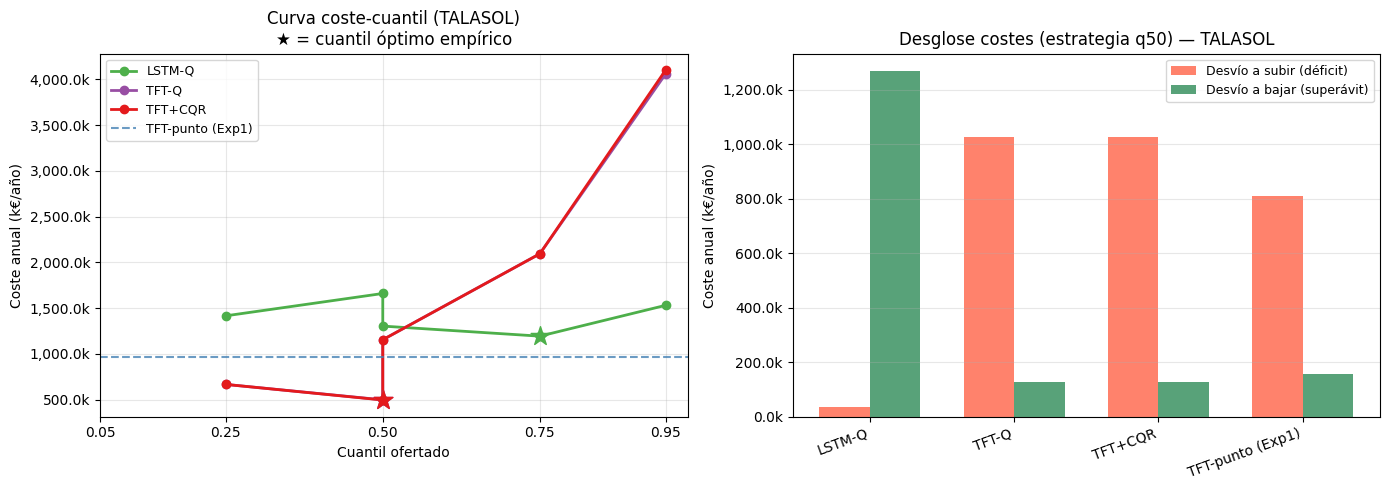

Figura guardada: prob_value_fixed_strategy.png


In [8]:
# ---------------------------------------------------------------------------
# CELDA 7 — Visualización estrategias fijas
# ---------------------------------------------------------------------------

if len(df_fixed) > 0 and preds:
    modelos_q = [m for m in ['LSTM-Q', 'TFT-Q', 'TFT+CQR'] if m in preds]
    n_q = len(modelos_q)

    colors_mod = {'LSTM-Q': '#4daf4a', 'TFT-Q': '#984ea3', 'TFT+CQR': '#e41a1c'}
    cuantil_labels = [0.05, 0.25, 0.50, 0.75, 0.95]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel izquierdo: coste por cuantil (curva en U)
    ax = axes[0]
    for modelo in modelos_q:
        sub = df_fixed[df_fixed['modelo'] == modelo].sort_values('cuantil')
        ax.plot(sub['cuantil'], sub['coste_anual_eur'] / 1e3,
                marker='o', label=modelo, color=colors_mod.get(modelo, 'gray'), linewidth=2)
        # Marcar cuantil óptimo
        best = sub.loc[sub['coste_anual_eur'].idxmin()]
        ax.scatter([best['cuantil']], [best['coste_anual_eur'] / 1e3],
                   marker='*', s=200, color=colors_mod.get(modelo, 'gray'), zorder=5)

    # Añadir referencia TFT punto
    if tft_point is not None and 'TFT-punto (Exp1)' in df_fixed['modelo'].values:
        ref_cost = df_fixed[df_fixed['modelo'] == 'TFT-punto (Exp1)']['coste_anual_eur'].values[0]
        ax.axhline(ref_cost / 1e3, color='steelblue', linestyle='--',
                   linewidth=1.5, label='TFT-punto (Exp1)', alpha=0.8)

    ax.set_xlabel('Cuantil ofertado')
    ax.set_ylabel('Coste anual (k€/año)')
    ax.set_title('Curva coste-cuantil (TALASOL)\n★ = cuantil óptimo empírico')
    ax.set_xticks(cuantil_labels)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}k'))

    # Panel derecho: desglose desvio_subir vs desvio_bajar (cuantil q50)
    ax2 = axes[1]
    models_all = modelos_q + (['TFT-punto (Exp1)'] if tft_point is not None else [])
    x_pos = np.arange(len(models_all))
    subir_vals, bajar_vals = [], []
    for m in models_all:
        sub_m = df_fixed[df_fixed['modelo'] == m]
        if m == 'TFT-punto (Exp1)':
            row = sub_m.iloc[0]
        else:
            row = sub_m[sub_m['estrategia'] == 'q50 (mediana)']
            if len(row) == 0:
                subir_vals.append(0); bajar_vals.append(0); continue
            row = row.iloc[0]
        subir_vals.append(row['desvio_subir_eur'] / 1e3)
        bajar_vals.append(row['desvio_bajar_eur'] / 1e3)

    width = 0.35
    ax2.bar(x_pos - width/2, subir_vals, width, label='Desvío a subir (déficit)', color='tomato', alpha=0.8)
    ax2.bar(x_pos + width/2, bajar_vals, width, label='Desvío a bajar (superávit)', color='seagreen', alpha=0.8)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(models_all, rotation=20, ha='right')
    ax2.set_ylabel('Coste anual (k€/año)')
    ax2.set_title('Desglose costes (estrategia q50) — TALASOL')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}k'))

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'prob_value_fixed_strategy.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: prob_value_fixed_strategy.png')

---
## Bloque 3: Estrategia dinámica — Newsvendor

El cuantil óptimo varía hora a hora según los precios de mercado:
$$q^*(h) = \frac{c_{subir}(h)}{c_{subir}(h) + \max(0,\, SPOT(h) - p_{bajar}(h))}$$

Cuando el coste de déficit es alto respecto al spread de superávit → ser conservador (cuantil bajo).

In [9]:
# ---------------------------------------------------------------------------
# CELDA 8 — Implementación Newsvendor
# ---------------------------------------------------------------------------

def newsvendor_bid(df_preds, prices_df, quantiles=None):
    """
    Para cada hora calcula q*(h) y obtiene la oferta óptima por interpolación lineal.

    q*(h) = cobro_subir(h) / (cobro_subir(h) + max(0, SPOT(h) - pago_bajar(h)))

    Retorna:
        bids    : Series con la oferta óptima horaria
        q_stars : Series con el cuantil óptimo horario (0-1)
    """
    if quantiles is None:
        quantiles = QUANTILES
    q_arr = np.array(quantiles)
    q_col_names = [f'q_{int(q*100):02d}' for q in quantiles]

    # Verificar que existen las columnas de cuantil
    missing = [c for c in q_col_names if c not in df_preds.columns]
    if missing:
        raise ValueError(f'Columnas de cuantil no encontradas: {missing}')

    idx = df_preds.index.intersection(prices_df.index)
    bids, q_stars = [], []

    for ts in idx:
        cobro    = float(prices_df.loc[ts, 'cobro_subir_eur_mwh'])
        spot     = float(prices_df.loc[ts, 'spot_eur_mwh'])
        pago_baj = float(prices_df.loc[ts, 'pago_bajar_eur_mwh'])

        spread_sup = max(0.0, spot - pago_baj)
        denom = cobro + spread_sup
        q_star = cobro / denom if denom > 0 else 0.5
        q_star = float(np.clip(q_star, 0.0, 1.0))
        q_stars.append(q_star)

        row = df_preds.loc[ts, q_col_names].values.astype(float)
        bid = float(np.interp(q_star, q_arr, row))
        bids.append(bid)

    return pd.Series(bids, index=idx), pd.Series(q_stars, index=idx)


records_dyn = []
q_stars_all = {}

for modelo, df in preds.items():
    try:
        bid_series, q_star_series = newsvendor_bid(df, prices_test)
        q_stars_all[modelo] = q_star_series
        y_real_m = df.loc[bid_series.index, 'y_true']
        cost_dyn = calculate_imbalance_cost(y_real_m, bid_series, prices_test)
        records_dyn.append({
            'modelo':           modelo,
            'estrategia':       'newsvendor',
            'coste_test_eur':   cost_dyn['coste_total_eur'].sum(),
            'coste_anual_eur':  cost_dyn['coste_total_eur'].sum() * ANNUAL_FACTOR,
            'desvio_subir_eur': cost_dyn['desvio_subir_eur'].sum() * ANNUAL_FACTOR,
            'desvio_bajar_eur': cost_dyn['desvio_bajar_eur'].sum() * ANNUAL_FACTOR,
            'q_star_mean':      q_star_series.mean(),
            'q_star_std':       q_star_series.std(),
        })
        print(f'  {modelo}: q*_medio={q_star_series.mean():.3f} | coste={cost_dyn["coste_total_eur"].sum()*ANNUAL_FACTOR:,.0f} €/año')
    except Exception as e:
        print(f'  AVISO: {modelo} — error en newsvendor_bid: {e}')

df_dyn = pd.DataFrame(records_dyn)
if len(df_dyn) > 0:
    print('\n=== Newsvendor vs. estrategia fija óptima ===')
    for _, row in df_dyn.iterrows():
        sub_f = df_fixed[df_fixed['modelo'] == row['modelo']]
        if len(sub_f) > 0:
            best_fixed = sub_f['coste_anual_eur'].min()
            delta = row['coste_anual_eur'] - best_fixed
            print(f'  {row["modelo"]}: newsvendor={row["coste_anual_eur"]:,.0f}€ | '
                  f'mejor_fijo={best_fixed:,.0f}€ | delta={delta:+,.0f}€')

  LSTM-Q: q*_medio=0.881 | coste=2,148,688 €/año
  TFT-Q: q*_medio=0.881 | coste=4,144,261 €/año
  TFT+CQR: q*_medio=0.881 | coste=4,182,253 €/año

=== Newsvendor vs. estrategia fija óptima ===
  LSTM-Q: newsvendor=2,148,688€ | mejor_fijo=1,194,005€ | delta=+954,683€
  TFT-Q: newsvendor=4,144,261€ | mejor_fijo=498,001€ | delta=+3,646,261€
  TFT+CQR: newsvendor=4,182,253€ | mejor_fijo=496,115€ | delta=+3,686,139€


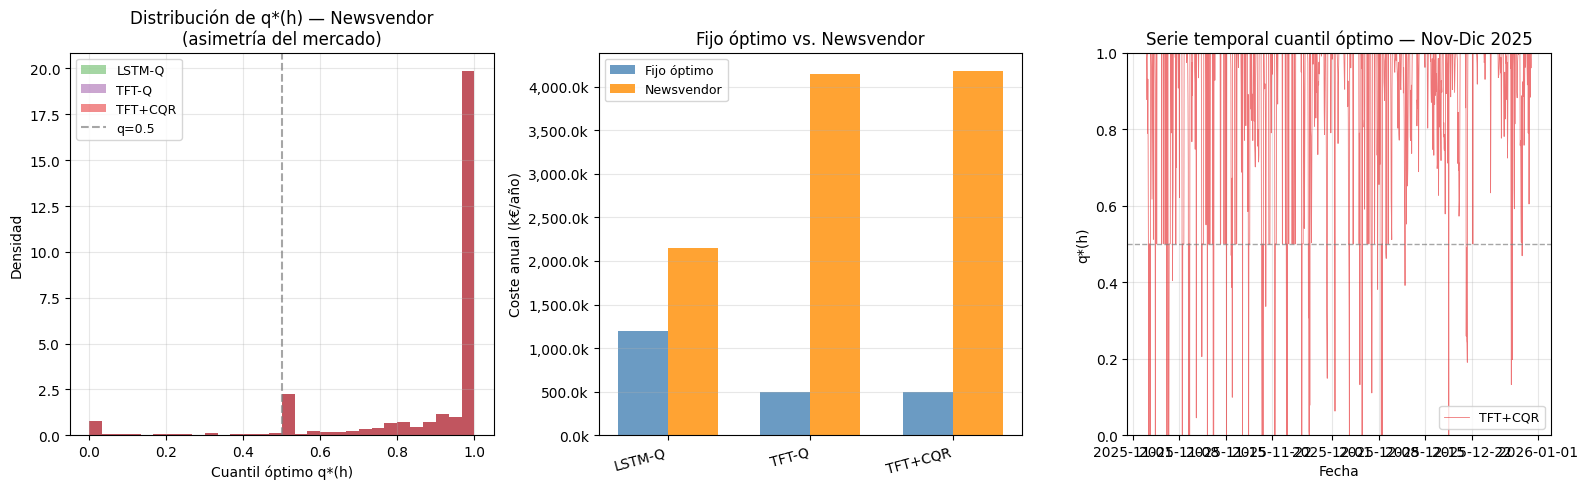

Figura guardada: prob_value_newsvendor.png


In [10]:
# ---------------------------------------------------------------------------
# CELDA 9 — Visualización Newsvendor
# ---------------------------------------------------------------------------

if q_stars_all and len(df_dyn) > 0:
    modelos_q = [m for m in ['LSTM-Q', 'TFT-Q', 'TFT+CQR'] if m in q_stars_all]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    colors_mod = {'LSTM-Q': '#4daf4a', 'TFT-Q': '#984ea3', 'TFT+CQR': '#e41a1c'}

    # Panel 1: Histograma de q*(h)
    ax = axes[0]
    for modelo in modelos_q:
        ax.hist(q_stars_all[modelo], bins=30, alpha=0.5,
                label=modelo, color=colors_mod.get(modelo, 'gray'), density=True)
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='q=0.5')
    ax.set_xlabel('Cuantil óptimo q*(h)')
    ax.set_ylabel('Densidad')
    ax.set_title('Distribución de q*(h) — Newsvendor\n(asimetría del mercado)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Panel 2: Comparativa fijo óptimo vs. newsvendor
    ax2 = axes[1]
    bar_data = []
    for modelo in modelos_q:
        sub_f = df_fixed[df_fixed['modelo'] == modelo]
        best_f = sub_f['coste_anual_eur'].min() if len(sub_f) > 0 else np.nan
        sub_d = df_dyn[df_dyn['modelo'] == modelo]
        cost_d = sub_d['coste_anual_eur'].values[0] if len(sub_d) > 0 else np.nan
        bar_data.append({'modelo': modelo, 'Fijo óptimo': best_f, 'Newsvendor': cost_d})

    df_bar = pd.DataFrame(bar_data).set_index('modelo')
    x = np.arange(len(df_bar))
    width = 0.35
    ax2.bar(x - width/2, df_bar['Fijo óptimo'] / 1e3, width,
            label='Fijo óptimo', color='steelblue', alpha=0.8)
    ax2.bar(x + width/2, df_bar['Newsvendor'] / 1e3, width,
            label='Newsvendor', color='darkorange', alpha=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels(df_bar.index, rotation=15, ha='right')
    ax2.set_ylabel('Coste anual (k€/año)')
    ax2.set_title('Fijo óptimo vs. Newsvendor')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}k'))

    # Panel 3: Serie temporal de q*(h) — si hay datos de un modelo TFT
    ax3 = axes[2]
    for modelo in ['TFT+CQR', 'TFT-Q']:
        if modelo in q_stars_all:
            ax3.plot(q_stars_all[modelo].index, q_stars_all[modelo].values,
                     alpha=0.6, linewidth=0.6, color=colors_mod.get(modelo, 'gray'),
                     label=modelo)
            break  # solo uno para legibilidad
    ax3.axhline(0.5, color='gray', linestyle='--', alpha=0.7, linewidth=1)
    ax3.set_xlabel('Fecha')
    ax3.set_ylabel('q*(h)')
    ax3.set_title('Serie temporal cuantil óptimo — Nov-Dic 2025')
    ax3.set_ylim(0, 1)
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'prob_value_newsvendor.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: prob_value_newsvendor.png')

---
## Bloque 4: EVPI — Expected Value of Perfect Information

- **Oracle:** bid = y_true en cada hora → cero desvíos → coste = 0 (cota inferior teórica).  
- **EVPI** = coste(mejor estrategia) − 0 = valor económico de información perfecta.  
- Es el **techo** del valor que puede añadir seguir mejorando el modelo.

EVPI (valor de información perfecta): 496,115 €/año
(= coste de la mejor estrategia disponible, porque oracle=0)

           Estrategia  coste_anual_eur
 TFT+CQR (newsvendor)     4.182253e+06
   TFT-Q (newsvendor)     4.144261e+06
 LSTM-Q (fijo óptimo)     1.194005e+06
     TFT-punto (Exp1)     9.654049e+05
  TFT-Q (fijo óptimo)     4.980008e+05
TFT+CQR (fijo óptimo)     4.961149e+05
    Oracle (perfecto)     0.000000e+00


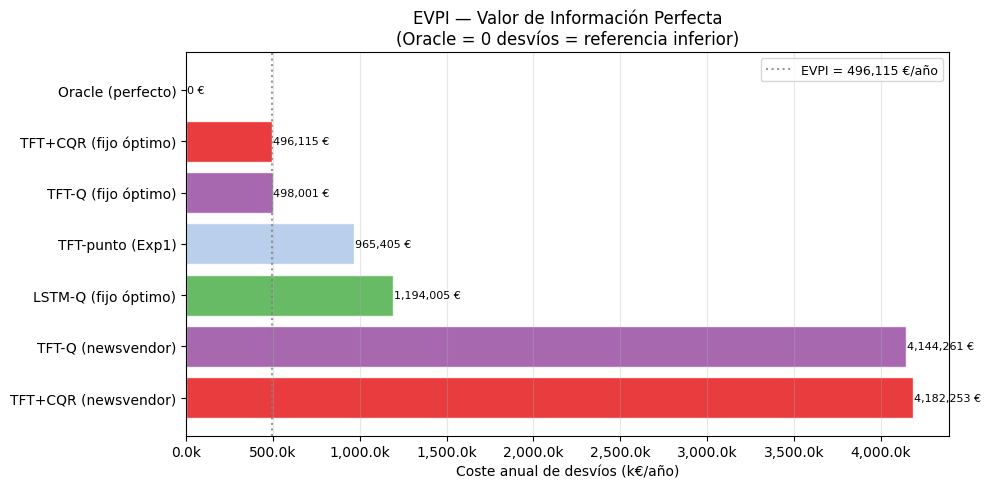

Figura guardada: prob_value_evpi.png


In [11]:
# ---------------------------------------------------------------------------
# CELDA 10 — EVPI y waterfall chart
# ---------------------------------------------------------------------------

if preds:
    # Usar TFT-Q como base para el análisis EVPI (mejor modelo Exp 3)
    ref_modelo = 'TFT-Q' if 'TFT-Q' in preds else next(iter(preds))
    df_ref = preds[ref_modelo]
    y_real_ref = df_ref['y_true']

    # Oracle: predicción perfecta → coste = 0
    cost_oracle = calculate_imbalance_cost(y_real_ref, y_real_ref, prices_test)
    assert cost_oracle['coste_total_eur'].sum() < 1e-6, 'Oracle debe tener coste ~0'

    # Construir tabla EVPI
    evpi_rows = []

    # TFT punto (referencia)
    if tft_point is not None:
        ref_f = df_fixed[df_fixed['modelo'] == 'TFT-punto (Exp1)']
        if len(ref_f) > 0:
            evpi_rows.append({'Estrategia': 'TFT-punto (Exp1)', 'coste_anual_eur': ref_f['coste_anual_eur'].values[0]})

    # Mejor cuantil fijo por modelo
    for modelo in ['LSTM-Q', 'TFT-Q', 'TFT+CQR']:
        sub_f = df_fixed[df_fixed['modelo'] == modelo]
        if len(sub_f) > 0:
            best_row = sub_f.loc[sub_f['coste_anual_eur'].idxmin()]
            evpi_rows.append({'Estrategia': f'{modelo} (fijo óptimo)',
                              'coste_anual_eur': best_row['coste_anual_eur']})

    # Newsvendor
    for modelo in ['TFT-Q', 'TFT+CQR']:
        sub_d = df_dyn[df_dyn['modelo'] == modelo] if len(df_dyn) > 0 else pd.DataFrame()
        if len(sub_d) > 0:
            evpi_rows.append({'Estrategia': f'{modelo} (newsvendor)',
                              'coste_anual_eur': sub_d['coste_anual_eur'].values[0]})

    # Oracle
    evpi_rows.append({'Estrategia': 'Oracle (perfecto)', 'coste_anual_eur': 0.0})

    df_evpi = pd.DataFrame(evpi_rows)
    df_evpi = df_evpi.sort_values('coste_anual_eur', ascending=False).reset_index(drop=True)

    # EVPI = coste de la mejor estrategia (vs oracle)
    best_strategy_cost = df_evpi.loc[df_evpi['Estrategia'] != 'Oracle (perfecto)', 'coste_anual_eur'].min()
    EVPI = best_strategy_cost  # oracle=0
    print(f'EVPI (valor de información perfecta): {EVPI:,.0f} €/año')
    print(f'(= coste de la mejor estrategia disponible, porque oracle=0)\n')
    print(df_evpi.to_string(index=False))

    # Waterfall chart
    fig, ax = plt.subplots(figsize=(10, 5))
    colors_evpi = []
    for i, row in df_evpi.iterrows():
        if row['Estrategia'] == 'Oracle (perfecto)':
            colors_evpi.append('#2ca02c')  # verde
        elif 'TFT-punto' in row['Estrategia']:
            colors_evpi.append('#aec7e8')  # azul claro
        elif 'CQR' in row['Estrategia']:
            colors_evpi.append('#e41a1c')  # rojo
        elif 'TFT-Q' in row['Estrategia']:
            colors_evpi.append('#984ea3')  # morado
        else:
            colors_evpi.append('#4daf4a')  # verde medio

    bars = ax.barh(df_evpi['Estrategia'], df_evpi['coste_anual_eur'] / 1e3,
                   color=colors_evpi, alpha=0.85, edgecolor='white')
    ax.axvline(EVPI / 1e3, color='gray', linestyle=':', linewidth=1.5,
               label=f'EVPI = {EVPI:,.0f} €/año', alpha=0.8)

    # Anotaciones
    for bar, (_, row) in zip(bars, df_evpi.iterrows()):
        val = row['coste_anual_eur']
        ax.text(val / 1e3 + EVPI / 1e3 * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:,.0f} €', va='center', ha='left', fontsize=8)

    ax.set_xlabel('Coste anual de desvíos (k€/año)')
    ax.set_title('EVPI — Valor de Información Perfecta\n(Oracle = 0 desvíos = referencia inferior)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}k'))
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'prob_value_evpi.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: prob_value_evpi.png')

---
## Bloque 5: Valor de la calibración CQR

TFT-Q raw tiene coverage_90 = 59.7% (infracobertura severa).  
TFT+CQR eleva la cobertura a 77.8%.  
¿Cuánto vale esa mejora en términos económicos?

In [12]:
# ---------------------------------------------------------------------------
# CELDA 11 — Valor económico de la calibración CQR
# ---------------------------------------------------------------------------

if 'TFT-Q' in preds and 'TFT+CQR' in preds:
    print('=== Comparación TFT-Q vs TFT+CQR ===')
    print(f'(coverage_90: TFT-Q=59.7% / TFT+CQR=77.8% — Exp 3 resultados)')
    print()

    # Tabla: 4 celdas = {TFT-Q, TFT+CQR} × {fijo óptimo, newsvendor}
    rows_cqr = []
    for modelo in ['TFT-Q', 'TFT+CQR']:
        # Fijo óptimo
        sub_f = df_fixed[df_fixed['modelo'] == modelo]
        best_f = sub_f.loc[sub_f['coste_anual_eur'].idxmin()] if len(sub_f) > 0 else None

        # Newsvendor
        sub_d = df_dyn[df_dyn['modelo'] == modelo] if len(df_dyn) > 0 else pd.DataFrame()
        cost_d = sub_d['coste_anual_eur'].values[0] if len(sub_d) > 0 else np.nan

        rows_cqr.append({
            'Modelo': modelo,
            'Fijo óptimo (€/año)': best_f['coste_anual_eur'] if best_f is not None else np.nan,
            'Cuantil óptimo': best_f['estrategia'] if best_f is not None else '-',
            'Newsvendor (€/año)': cost_d,
        })

    df_cqr = pd.DataFrame(rows_cqr)
    print(df_cqr.to_string(index=False))

    # Ahorro por CQR
    if len(df_cqr) == 2:
        for col in ['Fijo óptimo (€/año)', 'Newsvendor (€/año)']:
            tftq_cost = df_cqr.loc[df_cqr['Modelo'] == 'TFT-Q', col].values[0]
            cqr_cost  = df_cqr.loc[df_cqr['Modelo'] == 'TFT+CQR', col].values[0]
            if not (np.isnan(tftq_cost) or np.isnan(cqr_cost)):
                ahorro = tftq_cost - cqr_cost
                pct = ahorro / tftq_cost * 100 if tftq_cost != 0 else 0
                print(f'\nAhorro CQR ({col}): {ahorro:+,.0f} €/año ({pct:+.1f}%)')

    # Análisis de cobertura por cuantil: ¿cuántas horas fuera del intervalo → coste?
    print('\n=== Análisis por cuantil: horas fuera de rango vs coste ===')
    for modelo in ['TFT-Q', 'TFT+CQR']:
        if modelo not in preds:
            continue
        df_m = preds[modelo]
        y_real_m = df_m['y_true']
        print(f'\n  {modelo}:')
        for col, label in zip(Q_COLS, Q_LABELS):
            if col not in df_m.columns:
                continue
            q_val = df_m[col]
            # Horas donde y_real > q (infra-cobertura por ese cuantil → más desvíos a subir)
            n_out = (y_real_m > q_val).sum()
            cost_df = calculate_imbalance_cost(y_real_m, q_val, prices_test)
            print(f'    {label}: {n_out} horas fuera | coste={cost_df["coste_total_eur"].sum()*ANNUAL_FACTOR:,.0f} €/año')

elif 'TFT-Q' not in preds or 'TFT+CQR' not in preds:
    print('Bloque 5 requiere TFT-Q y TFT+CQR. Ejecutar notebook 02_tft_quantile.ipynb primero.')

=== Comparación TFT-Q vs TFT+CQR ===
(coverage_90: TFT-Q=59.7% / TFT+CQR=77.8% — Exp 3 resultados)

 Modelo  Fijo óptimo (€/año)    Cuantil óptimo  Newsvendor (€/año)
  TFT-Q        498000.755903 q05 (conservador)        4.144261e+06
TFT+CQR        496114.857643 q05 (conservador)        4.182253e+06

Ahorro CQR (Fijo óptimo (€/año)): +1,886 €/año (+0.4%)

Ahorro CQR (Newsvendor (€/año)): -37,992 €/año (-0.9%)

=== Análisis por cuantil: horas fuera de rango vs coste ===

  TFT-Q:
    q05 (conservador): 494 horas fuera | coste=498,001 €/año
    q25: 384 horas fuera | coste=666,802 €/año
    q50 (mediana): 256 horas fuera | coste=1,154,754 €/año
    q75: 142 horas fuera | coste=2,094,253 €/año
    q95 (optimista): 57 horas fuera | coste=4,057,452 €/año

  TFT+CQR:
    q05 (conservador): 494 horas fuera | coste=496,115 €/año
    q25: 384 horas fuera | coste=666,802 €/año
    q50 (mediana): 256 horas fuera | coste=1,154,754 €/año
    q75: 142 horas fuera | coste=2,094,253 €/año
    q95 (opt

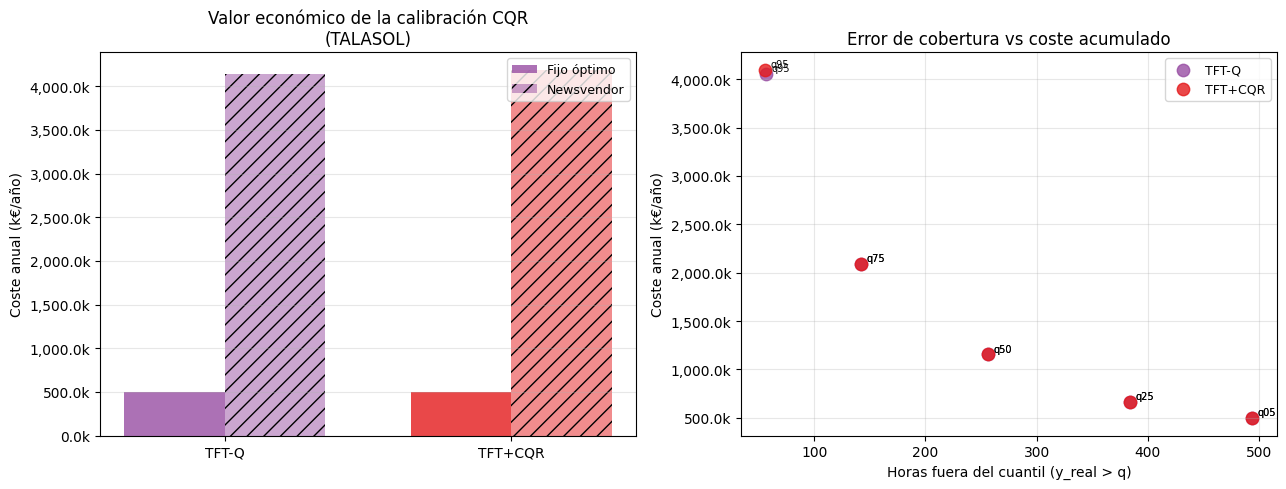

Figura guardada: prob_value_cqr_analysis.png


In [13]:
# ---------------------------------------------------------------------------
# CELDA 11b — Visualización CQR
# ---------------------------------------------------------------------------

if 'TFT-Q' in preds and 'TFT+CQR' in preds:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Panel izq: tabla en barras — fijo óptimo y newsvendor para TFT-Q vs CQR
    ax = axes[0]
    modelos_cqr = ['TFT-Q', 'TFT+CQR']
    costes_fijo = []
    costes_nv   = []
    for m in modelos_cqr:
        sf = df_fixed[df_fixed['modelo'] == m]
        costes_fijo.append(sf['coste_anual_eur'].min() / 1e3 if len(sf) > 0 else np.nan)
        sd = df_dyn[df_dyn['modelo'] == m] if len(df_dyn) > 0 else pd.DataFrame()
        costes_nv.append(sd['coste_anual_eur'].values[0] / 1e3 if len(sd) > 0 else np.nan)

    x = np.arange(len(modelos_cqr))
    w = 0.35
    ax.bar(x - w/2, costes_fijo, w, label='Fijo óptimo', color=['#984ea3', '#e41a1c'], alpha=0.8)
    ax.bar(x + w/2, costes_nv,   w, label='Newsvendor',  color=['#984ea3', '#e41a1c'], alpha=0.5,
           hatch='//')
    ax.set_xticks(x)
    ax.set_xticklabels(modelos_cqr)
    ax.set_ylabel('Coste anual (k€/año)')
    ax.set_title('Valor económico de la calibración CQR\n(TALASOL)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}k'))

    # Panel der: scatter — horas fuera de rango vs coste por cuantil
    ax2 = axes[1]
    colors_cqr = {'TFT-Q': '#984ea3', 'TFT+CQR': '#e41a1c'}
    for modelo in modelos_cqr:
        if modelo not in preds:
            continue
        df_m = preds[modelo]
        y_real_m = df_m['y_true']
        n_out_list, coste_list, label_list = [], [], []
        for col, lab in zip(Q_COLS, Q_LABELS):
            if col not in df_m.columns:
                continue
            n_out = (y_real_m > df_m[col]).sum()
            cost_df = calculate_imbalance_cost(y_real_m, df_m[col], prices_test)
            n_out_list.append(n_out)
            coste_list.append(cost_df['coste_total_eur'].sum() * ANNUAL_FACTOR / 1e3)
            label_list.append(lab)
        ax2.scatter(n_out_list, coste_list, label=modelo,
                    color=colors_cqr.get(modelo, 'gray'), s=80, alpha=0.8)
        for n, c, lab in zip(n_out_list, coste_list, label_list):
            ax2.annotate(lab.split('(')[0].strip(), (n, c), fontsize=7,
                         textcoords='offset points', xytext=(4, 2))

    ax2.set_xlabel('Horas fuera del cuantil (y_real > q)')
    ax2.set_ylabel('Coste anual (k€/año)')
    ax2.set_title('Error de cobertura vs coste acumulado')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}k'))

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'prob_value_cqr_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: prob_value_cqr_analysis.png')

---
## Bloque 6: Comparación global Exp 1 vs Exp 3

Tabla resumen ordenada por coste anual, con ahorro relativo vs TFT-punto.

In [14]:
# ---------------------------------------------------------------------------
# CELDA 12 — Tabla resumen global Exp 1 vs Exp 3
# ---------------------------------------------------------------------------

# Ingresos SPOT en el periodo de test (referencia para % de penalización)
if preds:
    ref_df = next(iter(preds.values()))
    y_real_global = ref_df['y_true']
    ingresos_spot_test = (y_real_global * 0.25 * prices_test.loc[y_real_global.index, 'spot_eur_mwh']).sum()
    ingresos_spot_anual = ingresos_spot_test * ANNUAL_FACTOR
    print(f'Ingresos SPOT estimados: {ingresos_spot_test:,.0f} € (test) | {ingresos_spot_anual:,.0f} €/año')
else:
    ingresos_spot_anual = np.nan

# Compilar tabla resumen
summary_rows = []

# TFT punto (Exp 1) — referencia
if tft_point is not None and 'TFT-punto (Exp1)' in df_fixed['modelo'].values:
    ref_cost = df_fixed[df_fixed['modelo'] == 'TFT-punto (Exp1)']['coste_anual_eur'].values[0]
    summary_rows.append({'Modelo': 'TFT-punto (Exp1)', 'Estrategia': 'punto',
                         'Coste anual (€)': ref_cost})
    TFT_POINT_COST = ref_cost
else:
    TFT_POINT_COST = np.nan

# Estrategias cuantílicas
for modelo in ['LSTM-Q', 'TFT-Q', 'TFT+CQR']:
    sub_f = df_fixed[df_fixed['modelo'] == modelo]
    if len(sub_f) == 0:
        continue

    # q50
    row_q50 = sub_f[sub_f['estrategia'] == 'q50 (mediana)']
    if len(row_q50) > 0:
        summary_rows.append({'Modelo': modelo, 'Estrategia': 'q50',
                             'Coste anual (€)': row_q50['coste_anual_eur'].values[0]})

    # Fijo óptimo
    best_f = sub_f.loc[sub_f['coste_anual_eur'].idxmin()]
    summary_rows.append({'Modelo': modelo, 'Estrategia': f'{best_f["estrategia"]} (óptimo)',
                         'Coste anual (€)': best_f['coste_anual_eur']})

    # Newsvendor
    sub_d = df_dyn[df_dyn['modelo'] == modelo] if len(df_dyn) > 0 else pd.DataFrame()
    if len(sub_d) > 0:
        summary_rows.append({'Modelo': modelo, 'Estrategia': 'newsvendor',
                             'Coste anual (€)': sub_d['coste_anual_eur'].values[0]})

# Oracle
summary_rows.append({'Modelo': 'Oracle', 'Estrategia': '-', 'Coste anual (€)': 0.0})

df_summary = pd.DataFrame(summary_rows).sort_values('Coste anual (€)').reset_index(drop=True)

# Añadir columnas de ahorro y % ingresos
df_summary['Ahorro vs TFT-punto (€)'] = TFT_POINT_COST - df_summary['Coste anual (€)']
df_summary['% ahorro'] = (df_summary['Ahorro vs TFT-punto (€)'] / TFT_POINT_COST * 100).round(1)
df_summary['% ingresos SPOT'] = (df_summary['Coste anual (€)'] / ingresos_spot_anual * 100).round(2)

# Formatear para display
df_disp = df_summary.copy()
df_disp['Coste anual (€)'] = df_disp['Coste anual (€)'].map(lambda x: f'{x:,.0f}')
df_disp['Ahorro vs TFT-punto (€)'] = df_disp['Ahorro vs TFT-punto (€)'].map(lambda x: f'{x:+,.0f}')
print('=== Comparación global Exp 1 vs Exp 3 — TALASOL ===')
print(df_disp.to_string(index=False))

Ingresos SPOT estimados: 1,801,316 € (test) | 11,335,869 €/año
=== Comparación global Exp 1 vs Exp 3 — TALASOL ===
          Modelo                 Estrategia Coste anual (€) Ahorro vs TFT-punto (€)  % ahorro  % ingresos SPOT
          Oracle                          -               0                +965,405     100.0             0.00
         TFT+CQR q05 (conservador) (óptimo)         496,115                +469,290      48.6             4.38
           TFT-Q q05 (conservador) (óptimo)         498,001                +467,404      48.4             4.39
TFT-punto (Exp1)                      punto         965,405                      +0       0.0             8.52
           TFT-Q                        q50       1,154,754                -189,349     -19.6            10.19
         TFT+CQR                        q50       1,154,754                -189,349     -19.6            10.19
          LSTM-Q               q75 (óptimo)       1,194,005                -228,600     -23.7            10.

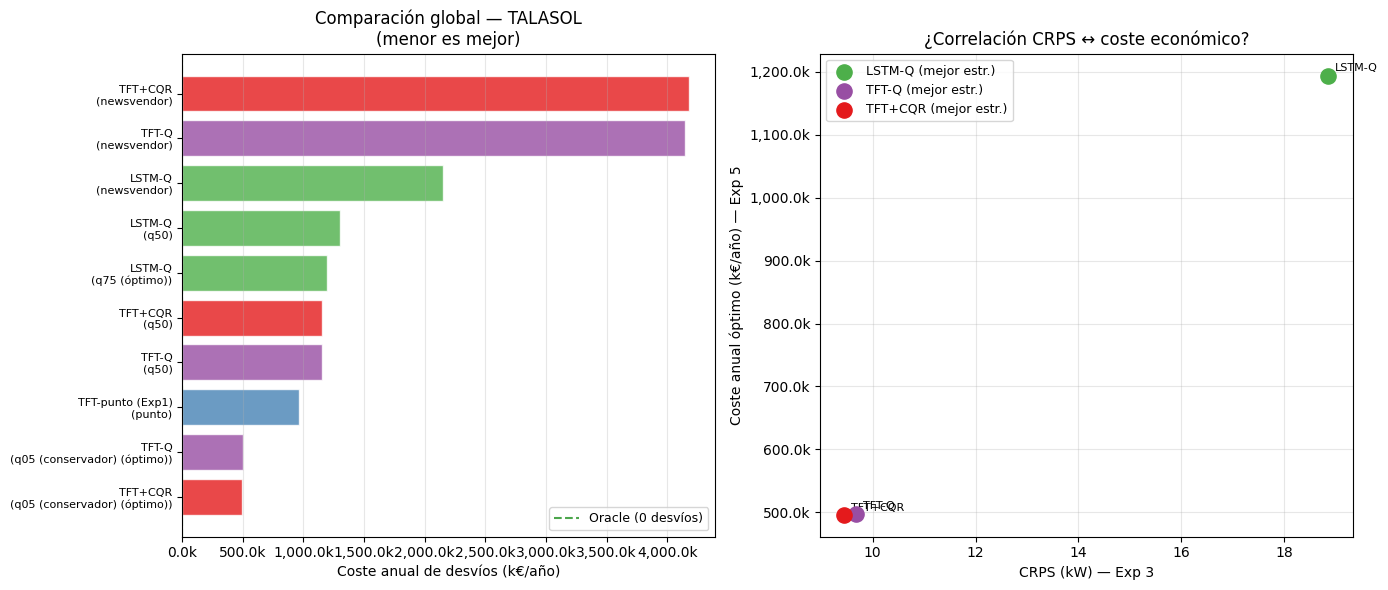

Figura guardada: prob_value_global_comparison.png


In [15]:
# ---------------------------------------------------------------------------
# CELDA 12b — Visualización comparación global
# ---------------------------------------------------------------------------

if len(df_summary) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Panel izquierdo: barras horizontales
    ax = axes[0]
    df_plot = df_summary[df_summary['Modelo'] != 'Oracle'].sort_values('Coste anual (€)', ascending=True)
    labels  = df_plot.apply(lambda r: f"{r['Modelo']}\n({r['Estrategia']})", axis=1)
    colors_bar = []
    for _, row in df_plot.iterrows():
        if 'TFT-punto' in row['Modelo']:
            colors_bar.append('steelblue')
        elif 'TFT+CQR' in row['Modelo']:
            colors_bar.append('#e41a1c')
        elif 'TFT-Q' in row['Modelo']:
            colors_bar.append('#984ea3')
        elif 'LSTM' in row['Modelo']:
            colors_bar.append('#4daf4a')
        else:
            colors_bar.append('gray')

    bars = ax.barh(range(len(df_plot)), df_plot['Coste anual (€)'] / 1e3,
                   color=colors_bar, alpha=0.8, edgecolor='white')
    ax.axvline(0, color='green', linestyle='--', linewidth=1.5, label='Oracle (0 desvíos)', alpha=0.7)
    ax.set_yticks(range(len(df_plot)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Coste anual de desvíos (k€/año)')
    ax.set_title('Comparación global — TALASOL\n(menor es mejor)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}k'))

    # Panel derecho: scatter CRPS vs coste_anual
    ax2 = axes[1]
    # Métricas CRPS de Exp 3 (resultados conocidos)
    crps_data = {
        'LSTM-Q':   {'CRPS': 18.86, 'color': '#4daf4a'},
        'TFT-Q':    {'CRPS':  9.67, 'color': '#984ea3'},
        'TFT+CQR':  {'CRPS':  9.45, 'color': '#e41a1c'},
    }

    for modelo, meta in crps_data.items():
        # Usar mejor estrategia disponible
        sub = df_summary[df_summary['Modelo'] == modelo]
        if len(sub) == 0:
            continue
        best_cost = sub['Coste anual (€)'].min()
        ax2.scatter([meta['CRPS']], [best_cost / 1e3],
                    color=meta['color'], s=120, zorder=5, label=f'{modelo} (mejor estr.)')
        ax2.annotate(modelo, (meta['CRPS'], best_cost / 1e3),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)

    ax2.set_xlabel('CRPS (kW) — Exp 3')
    ax2.set_ylabel('Coste anual óptimo (k€/año) — Exp 5')
    ax2.set_title('¿Correlación CRPS ↔ coste económico?')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}k'))

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'prob_value_global_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: prob_value_global_comparison.png')

---
## Bloque 7: Análisis de riesgo — VaR y CVaR diarios

El coste medio no basta para el gestor de riesgo.  
CVaR90 mide el coste esperado en el peor 10% de días.

In [16]:
# ---------------------------------------------------------------------------
# CELDA 13 — VaR y CVaR diarios por estrategia
# ---------------------------------------------------------------------------

def risk_metrics(cost_df):
    """Agrega costes por día y calcula VaR90 y CVaR90."""
    daily = cost_df['coste_total_eur'].resample('D').sum()
    var90  = daily.quantile(0.90)
    cvar90 = daily[daily >= var90].mean()
    return {
        'mean_daily': round(daily.mean(), 2),
        'std_daily':  round(daily.std(), 2),
        'var90':      round(var90, 2),
        'cvar90':     round(cvar90, 2),
        'max_daily':  round(daily.max(), 2),
        'daily':      daily,
    }


risk_records = []
daily_costs  = {}  # para visualización

# Calcular riesgo para cada modelo × su mejor estrategia
for modelo in ['LSTM-Q', 'TFT-Q', 'TFT+CQR']:
    if modelo not in preds:
        continue
    df_m = preds[modelo]
    y_real_m = df_m['y_true']

    # Mejor cuantil fijo
    sub_f = df_fixed[df_fixed['modelo'] == modelo]
    if len(sub_f) > 0:
        best_col = Q_COLS[sub_f['coste_anual_eur'].argmin()]
        cost_best = calculate_imbalance_cost(y_real_m, df_m[best_col], prices_test)
        rm = risk_metrics(cost_best)
        daily_costs[f'{modelo} (fijo)'] = rm['daily']
        risk_records.append({
            'Modelo': modelo, 'Estrategia': 'fijo óptimo',
            'Media diaria (€)': rm['mean_daily'], 'Std (€)': rm['std_daily'],
            'VaR90 (€)': rm['var90'], 'CVaR90 (€)': rm['cvar90'],
            'Max diario (€)': rm['max_daily'],
        })

    # Newsvendor
    sub_d = df_dyn[df_dyn['modelo'] == modelo] if len(df_dyn) > 0 else pd.DataFrame()
    if len(sub_d) > 0 and modelo in q_stars_all:
        bid_series, _ = newsvendor_bid(df_m, prices_test)
        y_r = df_m.loc[bid_series.index, 'y_true']
        cost_nv = calculate_imbalance_cost(y_r, bid_series, prices_test)
        rm_nv = risk_metrics(cost_nv)
        daily_costs[f'{modelo} (newsvendor)'] = rm_nv['daily']
        risk_records.append({
            'Modelo': modelo, 'Estrategia': 'newsvendor',
            'Media diaria (€)': rm_nv['mean_daily'], 'Std (€)': rm_nv['std_daily'],
            'VaR90 (€)': rm_nv['var90'], 'CVaR90 (€)': rm_nv['cvar90'],
            'Max diario (€)': rm_nv['max_daily'],
        })

# Oracle
if preds:
    df_ref2 = next(iter(preds.values()))
    y_r_ref2 = df_ref2['y_true']
    cost_oracle2 = calculate_imbalance_cost(y_r_ref2, y_r_ref2, prices_test)
    rm_oracle = risk_metrics(cost_oracle2)
    daily_costs['Oracle'] = rm_oracle['daily']
    risk_records.append({
        'Modelo': 'Oracle', 'Estrategia': '-',
        'Media diaria (€)': 0.0, 'Std (€)': 0.0,
        'VaR90 (€)': 0.0, 'CVaR90 (€)': 0.0, 'Max diario (€)': 0.0,
    })

df_risk = pd.DataFrame(risk_records)
print('=== Análisis de riesgo diario ===')
print(df_risk.to_string(index=False))

=== Análisis de riesgo diario ===
 Modelo  Estrategia  Media diaria (€)  Std (€)  VaR90 (€)  CVaR90 (€)  Max diario (€)
 LSTM-Q fijo óptimo           3215.80  6269.40    9284.58    18238.67        36997.10
 LSTM-Q  newsvendor           5787.04  7717.63   14554.84    24287.78        42371.63
  TFT-Q fijo óptimo           1341.26  1941.48    2885.78     5783.67        11670.49
  TFT-Q  newsvendor          11161.70  7229.31   21010.00    25889.76        31476.41
TFT+CQR fijo óptimo           1336.18  1945.15    2885.45     5784.03        11690.41
TFT+CQR  newsvendor          11264.02  7248.10   21100.55    26025.91        31656.27
 Oracle           -              0.00     0.00       0.00        0.00            0.00


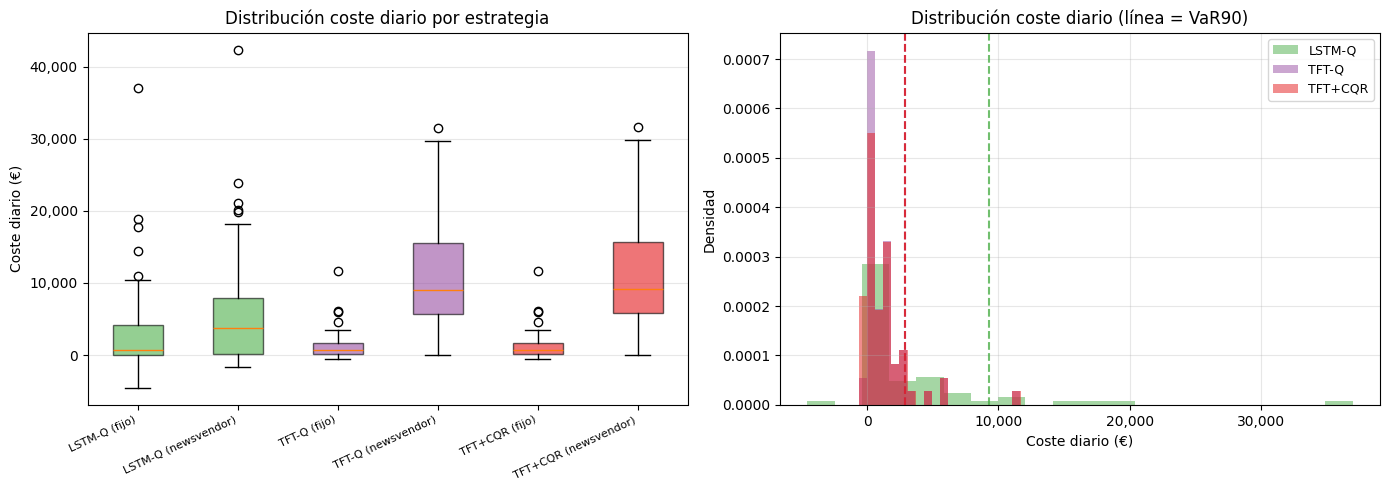

Figura guardada: prob_value_risk_analysis.png


In [17]:
# ---------------------------------------------------------------------------
# CELDA 13b — Visualización VaR/CVaR
# ---------------------------------------------------------------------------

if daily_costs and len(df_risk) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel izquierdo: boxplot costes diarios
    ax = axes[0]
    plot_keys = [k for k in daily_costs if k != 'Oracle']
    data_box  = [daily_costs[k].values for k in plot_keys]
    bp = ax.boxplot(data_box, labels=plot_keys, patch_artist=True, notch=False)
    colors_box = ['#4daf4a', '#4daf4a', '#984ea3', '#984ea3', '#e41a1c', '#e41a1c']
    for patch, color in zip(bp['boxes'], colors_box[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_xticklabels(plot_keys, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('Coste diario (€)')
    ax.set_title('Distribución coste diario por estrategia')
    ax.grid(True, alpha=0.3, axis='y')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # Panel derecho: histograma superpuesto para 3 modelos (mejor estrategia)
    ax2 = axes[1]
    colors_hist = {'LSTM-Q (fijo)': '#4daf4a', 'TFT-Q (fijo)': '#984ea3', 'TFT+CQR (fijo)': '#e41a1c'}
    for key, color in colors_hist.items():
        if key in daily_costs:
            ax2.hist(daily_costs[key], bins=20, alpha=0.5, color=color,
                     label=key.replace(' (fijo)', ''), density=True)
            # VaR90
            var90 = daily_costs[key].quantile(0.90)
            ax2.axvline(var90, color=color, linestyle='--', linewidth=1.5, alpha=0.8)

    ax2.set_xlabel('Coste diario (€)')
    ax2.set_ylabel('Densidad')
    ax2.set_title('Distribución coste diario (línea = VaR90)')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'prob_value_risk_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: prob_value_risk_analysis.png')

---
## Bloque 8: Resumen y exportación

In [18]:
# ---------------------------------------------------------------------------
# CELDA 14 — Tabla consolidada + exportación
# ---------------------------------------------------------------------------

# Combinar df_summary con df_risk para tabla final
if len(df_summary) > 0 and len(df_risk) > 0:
    # Merge por Modelo + Estrategia
    df_final = df_summary.merge(
        df_risk.rename(columns={'Estrategia': 'est_risk'}).assign(
            Estrategia=lambda d: d.apply(
                lambda r: 'fijo óptimo' if 'fijo' in str(r['est_risk']) else r['est_risk'], axis=1
            )
        ),
        on=['Modelo', 'Estrategia'], how='left'
    ).drop(columns=['est_risk'], errors='ignore')

    # Añadir columnas de estrategia fija Newsvendor desde df_dyn
    if len(df_dyn) > 0:
        for _, row in df_dyn.iterrows():
            mask = (df_final['Modelo'] == row['modelo']) & (df_final['Estrategia'] == 'newsvendor')
            if mask.any():
                df_final.loc[mask, 'desvio_subir_anual'] = row.get('desvio_subir_eur', np.nan)
                df_final.loc[mask, 'desvio_bajar_anual'] = row.get('desvio_bajar_eur', np.nan)

    # Añadir desvios de df_fixed
    for _, row in df_fixed.iterrows():
        model_str = row['modelo']
        strat_str = row['estrategia']
        mask = (df_final['Modelo'] == model_str)
        if mask.any():
            # Match por coste
            cost_match = abs(df_final.loc[mask, 'Coste anual (€)'] - row['coste_anual_eur']) < 1
            if cost_match.any():
                idx_m = df_final[mask & cost_match].index
                df_final.loc[idx_m, 'desvio_subir_anual'] = row['desvio_subir_eur']
                df_final.loc[idx_m, 'desvio_bajar_anual'] = row['desvio_bajar_eur']

    # Exportar
    out_path = OUT_DIR / 'economic_valuation_ex3_full.csv'
    df_final.to_csv(out_path, index=False)
    print(f'Tabla exportada: {out_path}')

    print()
    print('=== Tabla final ===')
    cols_show = ['Modelo', 'Estrategia', 'Coste anual (€)',
                 'Ahorro vs TFT-punto (€)', '% ahorro', '% ingresos SPOT']
    if 'VaR90 (€)' in df_final.columns:
        cols_show += ['VaR90 (€)', 'CVaR90 (€)']
    print(df_final[cols_show].sort_values('Coste anual (€)').to_string(index=False))

Tabla exportada: results/ex4_valuation/economic_valuation_ex3_full.csv

=== Tabla final ===
          Modelo                 Estrategia  Coste anual (€)  Ahorro vs TFT-punto (€)  % ahorro  % ingresos SPOT  VaR90 (€)  CVaR90 (€)
          Oracle                          -     0.000000e+00             9.654049e+05     100.0             0.00       0.00        0.00
         TFT+CQR q05 (conservador) (óptimo)     4.961149e+05             4.692900e+05      48.6             4.38        NaN         NaN
           TFT-Q q05 (conservador) (óptimo)     4.980008e+05             4.674041e+05      48.4             4.39        NaN         NaN
TFT-punto (Exp1)                      punto     9.654049e+05             0.000000e+00       0.0             8.52        NaN         NaN
           TFT-Q                        q50     1.154754e+06            -1.893489e+05     -19.6            10.19        NaN         NaN
         TFT+CQR                        q50     1.154754e+06            -1.893489e+05     -1

In [19]:
# ---------------------------------------------------------------------------
# CELDA 15 — Hallazgos clave
# ---------------------------------------------------------------------------

print('=' * 65)
print('  HALLAZGOS CLAVE — VALORACIÓN ECONÓMICA PROBABILÍSTICA')
print('=' * 65)

if tft_point is not None and 'TFT-punto (Exp1)' in df_fixed['modelo'].values:
    ref_c = df_fixed[df_fixed['modelo'] == 'TFT-punto (Exp1)']['coste_anual_eur'].values[0]
    print(f'\n[Referencia] TFT-punto (Exp1): {ref_c:,.0f} €/año')

if preds:
    print('\n[1] Cuantil óptimo empírico por modelo:')
    for modelo in ['LSTM-Q', 'TFT-Q', 'TFT+CQR']:
        sub_f = df_fixed[df_fixed['modelo'] == modelo]
        if len(sub_f) > 0:
            best = sub_f.loc[sub_f['coste_anual_eur'].idxmin()]
            print(f'  {modelo}: {best["estrategia"]} → {best["coste_anual_eur"]:,.0f} €/año')

if q_stars_all:
    print('\n[2] Cuantil medio pedido por el mercado (Newsvendor):')
    for modelo, qs in q_stars_all.items():
        print(f'  {modelo}: q*_medio = {qs.mean():.3f} (std={qs.std():.3f})')

if 'TFT-Q' in preds and 'TFT+CQR' in preds and len(df_fixed) > 0:
    sub_q  = df_fixed[(df_fixed['modelo'] == 'TFT-Q')]
    sub_cqr = df_fixed[(df_fixed['modelo'] == 'TFT+CQR')]
    if len(sub_q) > 0 and len(sub_cqr) > 0:
        best_q   = sub_q['coste_anual_eur'].min()
        best_cqr = sub_cqr['coste_anual_eur'].min()
        valor_cqr = best_q - best_cqr
        print(f'\n[3] Valor económico de la calibración CQR (fijo óptimo):')
        print(f'  TFT-Q:   {best_q:,.0f} €/año')
        print(f'  TFT+CQR: {best_cqr:,.0f} €/año')
        print(f'  Ahorro:  {valor_cqr:+,.0f} €/año ({valor_cqr/best_q*100:+.1f}%)')

if 'EVPI' in dir():
    print(f'\n[4] EVPI (brecha con oracle): {EVPI:,.0f} €/año')
    print(f'    (= valor máximo que puede añadir mejorar el modelo)')

if len(df_risk) > 0:
    print('\n[5] Riesgo (CVaR90 diario):')
    for _, row in df_risk.iterrows():
        if row['Modelo'] != 'Oracle':
            print(f'  {row["Modelo"]} ({row["Estrategia"]}): CVaR90={row["CVaR90 (€)"]:,.0f} €/día')

print()
print('--- Archivos generados ---')
for f in list(OUT_DIR.glob('economic_valuation_ex3*.csv')):
    print(f'  {f}')
for f in list(FIG_DIR.glob('prob_value_*.png')):
    print(f'  {f}')

print()
print('Notebook 02_probabilistic_value completado.')

  HALLAZGOS CLAVE — VALORACIÓN ECONÓMICA PROBABILÍSTICA

[Referencia] TFT-punto (Exp1): 965,405 €/año

[1] Cuantil óptimo empírico por modelo:
  LSTM-Q: q75 → 1,194,005 €/año
  TFT-Q: q05 (conservador) → 498,001 €/año
  TFT+CQR: q05 (conservador) → 496,115 €/año

[2] Cuantil medio pedido por el mercado (Newsvendor):
  LSTM-Q: q*_medio = 0.881 (std=0.230)
  TFT-Q: q*_medio = 0.881 (std=0.230)
  TFT+CQR: q*_medio = 0.881 (std=0.230)

[3] Valor económico de la calibración CQR (fijo óptimo):
  TFT-Q:   498,001 €/año
  TFT+CQR: 496,115 €/año
  Ahorro:  +1,886 €/año (+0.4%)

[4] EVPI (brecha con oracle): 496,115 €/año
    (= valor máximo que puede añadir mejorar el modelo)

[5] Riesgo (CVaR90 diario):
  LSTM-Q (fijo óptimo): CVaR90=18,239 €/día
  LSTM-Q (newsvendor): CVaR90=24,288 €/día
  TFT-Q (fijo óptimo): CVaR90=5,784 €/día
  TFT-Q (newsvendor): CVaR90=25,890 €/día
  TFT+CQR (fijo óptimo): CVaR90=5,784 €/día
  TFT+CQR (newsvendor): CVaR90=26,026 €/día

--- Archivos generados ---
  result